# 003 - Modelado de Alerta Temprana de Sobrecarga Localizada

Este notebook implementa el plan definido en `specs/003-modelado/plan.md`. 
El objetivo es predecir la probabilidad de que un centro de salud entre en "alta demanda" (shock logístico) en la semana $t+1$, utilizando información histórica y factores epidemiológicos medidos hasta la semana $t$.

**Nota:** Es un prerrequisito tener generado el dataset `dataset_salud/urg_resp_centro_semana.parquet`.

## 1. Importación de Librerías y Parámetros

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

# Modelos y Métricas
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, precision_recall_curve, auc, confusion_matrix, accuracy_score
from sklearn.preprocessing import StandardScaler

# Importar configuraciones
sys.path.append(r"c:\Proyectos\Diplomado-ML V2")
from configuraciones.configuraciones import PANEL_PARQUET

sns.set_theme(style="whitegrid")

## 2. Carga del Dataset

In [2]:
print(f"Cargando dataset preprocesado desde: {PANEL_PARQUET}")
try:
    df = pd.read_parquet(PANEL_PARQUET)
    print(f"Filas totales: {len(df):,}")
    display(df.head())
except FileNotFoundError:
    print("\n⚠️ ERROR: No se encontró el archivo parquet. Asegúrate de ejecutar el notebook 002_eda_dataset.ipynb primero.")

Cargando dataset preprocesado desde: c:\Proyectos\Diplomado-ML V2\dataset_salud\urg_resp_centro_semana.parquet
Filas totales: 9,016


,EstablecimientoCodigo,Anio,SemanaEstadistica,n_atenciones,n_0a4,n_5a14,n_65mas,n_hosp_resp,TipoUrgencia,NivelComplejidad,ServicioSaludCodigo,ComunaCodigo,Latitud,Longitud,umbral_alta_demanda,alta_demanda,pos_vrs,pos_flu,n_centros_vecinos
0,109100,2023,1,61,0,0,32,22,Urgencia Hospitalaria (UEH),Alta Complejidad,9,13108,-33.416586,-70.653318,NaN,<NA>,0.141414,0.040404,4
1,109100,2023,2,51,0,0,27,18,Urgencia Hospitalaria (UEH),Alta Complejidad,9,13108,-33.416586,-70.653318,NaN,<NA>,0.095238,0.047619,4
2,109100,2023,3,42,0,0,23,18,Urgencia Hospitalaria (UEH),Alta Complejidad,9,13108,-33.416586,-70.653318,NaN,<NA>,0.120879,0.054945,4
3,109100,2023,4,63,0,0,28,28,Urgencia Hospitalaria (UEH),Alta Complejidad,9,13108,-33.416586,-70.653318,NaN,<NA>,0.040000,0.080000,4
4,109100,2023,5,43,0,0,16,18,Urgencia Hospitalaria (UEH),Alta Complejidad,9,13108,-33.416586,-70.653318,68.812366,0,0.016949,0.050847,4


## 3. Prevención de Fuga de Datos (Data Leakage) ⚠️

Para predecir el target (`alta_demanda`) en la semana $t$, solo podemos usar información disponible en la semana $t-1$.
Por lo tanto, variables como `pos_vrs` y `pos_flu` deben ser **rezagadas (lag)**.

In [3]:
if 'df' in locals():
    # Ordenar estrictamente por tiempo para cada centro
    df = df.sort_values(['EstablecimientoCodigo', 'Anio', 'SemanaEstadistica']).copy()

    # Generar variables de rezago (lags) de 1, 2 y 3 semanas para la positividad viral y atenciones pasadas
    features_to_lag = ['n_atenciones', 'pos_vrs', 'pos_flu', 'n_0a4', 'n_5a14', 'n_65mas']
    
    for col in features_to_lag:
        for lag in [1, 2, 3]:
            df[f'{col}_lag{lag}'] = df.groupby('EstablecimientoCodigo')[col].shift(lag)

    # Eliminar filas con nulos generados por los rezagos o por el arranque en frío del umbral
    print(f"Filas originales: {len(df)}")
    df = df.dropna(subset=['alta_demanda'] + [f'{col}_lag1' for col in features_to_lag])
    
    # AÑADE ESTA LÍNEA PARA REPARAR LOS NULOS:
    df = df.fillna(0)
    
    df['alta_demanda'] = df['alta_demanda'].astype(int)
    print(f"Filas tras eliminar NAs por lags y arranque en frío: {len(df)}")

Filas originales: 9016
Filas tras eliminar NAs por lags y arranque en frío: 8771


## 4. Partición Temporal Estricta

- **Train:** 2023 - 2024
- **Test:** 2025 - 2026

No usamos variables contemporáneas de atenciones, solo lags, densidad poblacional y atributos de centro.

In [4]:
if 'df' in locals():
    # Definir características (Features)
    base_features = [
        'n_centros_vecinos',
        # Lags de Atenciones
        'n_atenciones_lag1', 'n_atenciones_lag2', 'n_atenciones_lag3',
        # Lags Epidemiológicos (VRS e Influenza)
        'pos_vrs_lag1', 'pos_vrs_lag2', 'pos_flu_lag1', 'pos_flu_lag2',
        # Lags Demográficos atenciones
        'n_0a4_lag1', 'n_65mas_lag1'
    ]
    
    # Opcional: One-Hot Encoding para Tipo de Urgencia (SAPU, SAR)
    if 'TipoUrgencia' in df.columns:
        df = pd.get_dummies(df, columns=['TipoUrgencia'], drop_first=True)
        dummy_cols = [c for c in df.columns if c.startswith('TipoUrgencia_')]
        base_features.extend(dummy_cols)

    # Split temporal
    train_mask = df['Anio'].isin([2023, 2024])
    test_mask = df['Anio'].isin([2025, 2026])

    X_train, y_train = df.loc[train_mask, base_features], df.loc[train_mask, 'alta_demanda']
    X_test, y_test = df.loc[test_mask, base_features], df.loc[test_mask, 'alta_demanda']

    # Escalar datos (importante para Regresión Logística con Lasso)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print(f"Dimensión Train: {X_train.shape} | Tasa Positivos: {y_train.mean()*100:.2f}%")
    print(f"Dimensión Test:  {X_test.shape} | Tasa Positivos: {y_test.mean()*100:.2f}%")

Dimensión Train: (4900, 13) | Tasa Positivos: 21.41%
Dimensión Test:  (3871, 13) | Tasa Positivos: 21.67%


## 5. Modelado
### 5.1 Baseline: Regresión Logística (Lasso / L1)
Actúa como filtro de variables e interpretabilidad lineal.

=== REPORTE REGRESIÓN LOGÍSTICA ===
              precision    recall  f1-score   support

           0       0.92      0.46      0.61      3032
           1       0.31      0.86      0.45       839

    accuracy                           0.55      3871
   macro avg       0.61      0.66      0.53      3871
weighted avg       0.79      0.55      0.58      3871



<python-user-base>\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
<python-user-base>\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


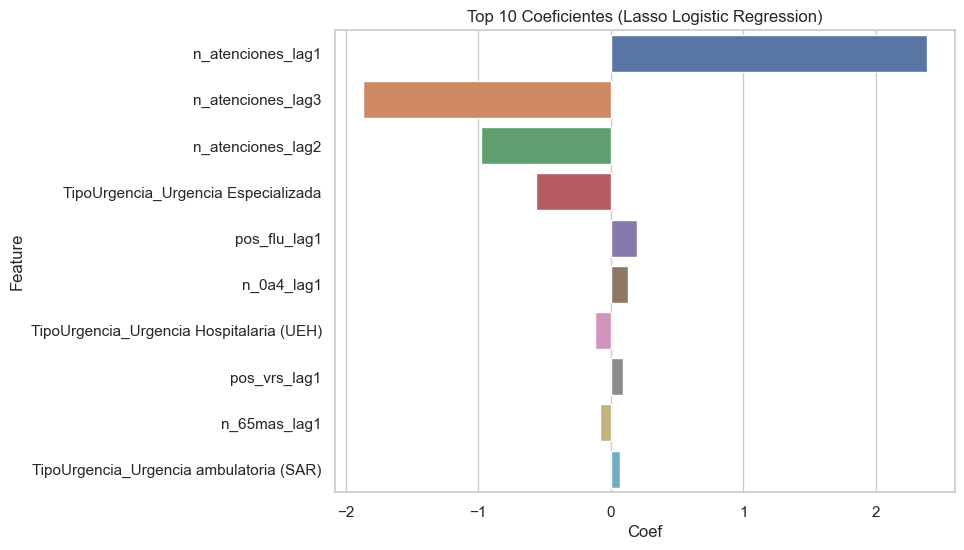

In [5]:
if 'X_train_scaled' in locals():
    # Utilizamos class_weight='balanced' debido a la baja tasa de positivos
    lr_model = LogisticRegression(penalty='l1', solver='liblinear', class_weight='balanced', random_state=42, C=0.1)
    lr_model.fit(X_train_scaled, y_train)
    
    # Predicciones
    lr_preds = lr_model.predict(X_test_scaled)
    lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]

    print("=== REPORTE REGRESIÓN LOGÍSTICA ===")
    print(classification_report(y_test, lr_preds))

    # Importancia de coeficientes (Selección de features)
    coefs = pd.DataFrame({'Feature': base_features, 'Coef': lr_model.coef_[0]})
    coefs['Abs_Coef'] = coefs['Coef'].abs()
    coefs = coefs.sort_values('Abs_Coef', ascending=False)
    
    plt.figure(figsize=(8, 6))
    sns.barplot(data=coefs.head(10), x='Coef', y='Feature', hue='Feature')
    plt.title('Top 10 Coeficientes (Lasso Logistic Regression)')
    plt.show()

### 5.2 Ensamblado: Random Forest
Modelo capaz de aprender reglas no lineales y cruces de variables (ej. alta inercia sumado a aumento viral).

=== REPORTE RANDOM FOREST ===
              precision    recall  f1-score   support

           0       0.76      0.62      0.68      3032
           1       0.17      0.28      0.21       839

    accuracy                           0.55      3871
   macro avg       0.47      0.45      0.45      3871
weighted avg       0.63      0.55      0.58      3871



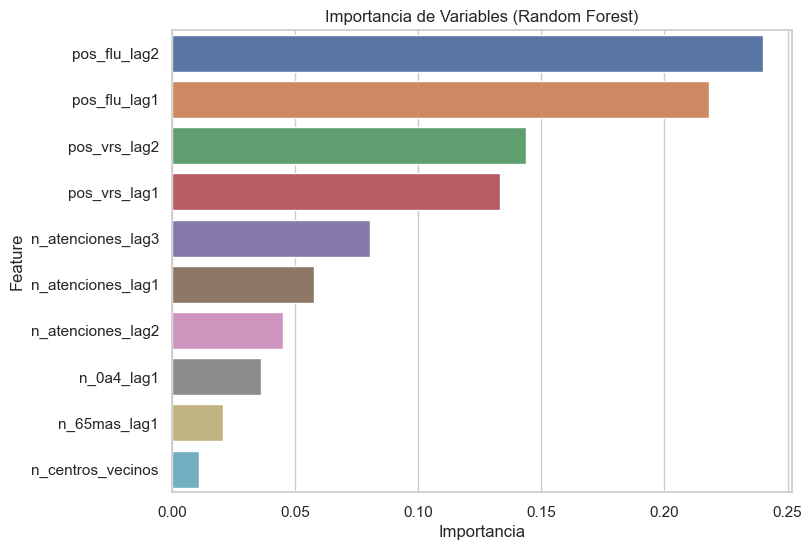

In [6]:
if 'X_train_scaled' in locals():
    # Random Forest con balanceo
    rf_model = RandomForestClassifier(n_estimators=100, max_depth=6, class_weight='balanced', random_state=42)
    # RF no necesita datos escalados, pero podemos usar los originales
    rf_model.fit(X_train, y_train)
    
    rf_preds = rf_model.predict(X_test)
    rf_probs = rf_model.predict_proba(X_test)[:, 1]

    print("=== REPORTE RANDOM FOREST ===")
    print(classification_report(y_test, rf_preds))

    # Feature Importance
    importances = pd.DataFrame({'Feature': base_features, 'Importancia': rf_model.feature_importances_})
    importances = importances.sort_values('Importancia', ascending=False)

    plt.figure(figsize=(8, 6))
    sns.barplot(data=importances.head(10), x='Importancia', y='Feature', hue='Feature')
    plt.title('Importancia de Variables (Random Forest)')
    plt.show()

## 6. Evaluación de Curva Precision-Recall
Dado el desbalance de clases, el área bajo la curva PR (PR-AUC) es nuestra métrica más fiel para medir el desempeño (mejor que el ROC-AUC o Accuracy).

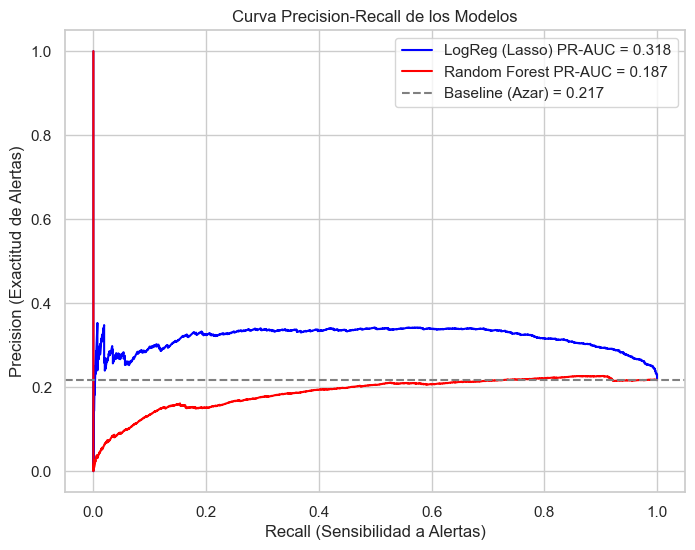

In [7]:
if 'lr_probs' in locals() and 'rf_probs' in locals():
    precision_lr, recall_lr, _ = precision_recall_curve(y_test, lr_probs)
    pr_auc_lr = auc(recall_lr, precision_lr)
    
    precision_rf, recall_rf, _ = precision_recall_curve(y_test, rf_probs)
    pr_auc_rf = auc(recall_rf, precision_rf)

    plt.figure(figsize=(8, 6))
    plt.plot(recall_lr, precision_lr, label=f'LogReg (Lasso) PR-AUC = {pr_auc_lr:.3f}', color='blue')
    plt.plot(recall_rf, precision_rf, label=f'Random Forest PR-AUC = {pr_auc_rf:.3f}', color='red')
    
    # Baseline PR-AUC = Tasa de casos positivos
    baseline = y_test.mean()
    plt.axhline(baseline, linestyle='--', color='gray', label=f'Baseline (Azar) = {baseline:.3f}')
    
    plt.xlabel('Recall (Sensibilidad a Alertas)')
    plt.ylabel('Precision (Exactitud de Alertas)')
    plt.title('Curva Precision-Recall de los Modelos')
    plt.legend()
    plt.show()

### XGBoost (Modelo Campeón)
Se utiliza XGBoost ajustando el peso de las clases positivas (`scale_pos_weight`) para combatir el desbalance.

In [ ]:
# Importar XGBoost
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, precision_recall_curve, auc
import matplotlib.pyplot as plt

if 'X_train' in locals():
    print("--- Entrenando Modelo Campeón: XGBoost ---")
    
    # Calcular peso para clases desbalanceadas (negativos / positivos)
    scale_weight = (len(y_train) - y_train.sum()) / y_train.sum()
    
    # Configuramos el modelo con parámetros conservadores para evitar overfitting
    xgb_model = XGBClassifier(
        n_estimators=150, 
        max_depth=5, 
        learning_rate=0.05, 
        scale_pos_weight=scale_weight,
        random_state=42,
        eval_metric='logloss'
    )
    
    # XGBoost no necesita datos escalados
    xgb_model.fit(X_train, y_train)
    
    xgb_preds = xgb_model.predict(X_test)
    xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
    
    print("=== REPORTE XGBOOST ===")
    print(classification_report(y_test, xgb_preds))
    
    # Calcular PR-AUC
    precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, xgb_probs)
    pr_auc_xgb = auc(recall_xgb, precision_xgb)
    
    # Gráfico Comparativo Final
    plt.figure(figsize=(10, 6))
    if 'recall_lr' in locals() and 'precision_lr' in locals():
        plt.plot(recall_lr, precision_lr, label=f'LogReg (Lasso) PR-AUC = {pr_auc_lr:.3f}', color='blue', alpha=0.5)
    if 'recall_rf' in locals() and 'precision_rf' in locals():
        plt.plot(recall_rf, precision_rf, label=f'Random Forest PR-AUC = {pr_auc_rf:.3f}', color='red', alpha=0.5)
    
    plt.plot(recall_xgb, precision_xgb, label=f'XGBoost PR-AUC = {pr_auc_xgb:.3f}', color='green', linewidth=2.5)
    
    baseline = y_test.mean()
    plt.axhline(baseline, linestyle='--', color='gray', label=f'Azar = {baseline:.3f}')
    
    plt.xlabel('Recall (Sensibilidad a Alertas)')
    plt.ylabel('Precision (Exactitud de Alertas)')
    plt.title('Comparativa Final de Modelos: Precision-Recall Curve')
    plt.legend()
    plt.show()


## 7. Historial y Respaldo Automático
Esta celda realiza un backup automático del notebook en la carpeta `historico/`.

In [8]:
import shutil
import time
import os
from IPython.display import Markdown, display
from sklearn.metrics import f1_score

# 1. Configuracion del Experimento
version_actual = "v2_xgboost"
cambio_breve = "Implementación de XGBoost con pesos balanceados"
cambio_extenso = """Se añade XGBoost (scale_pos_weight) para atacar la baja precisión del Baseline.
La hipótesis es que un modelo de ensamble tipo Boosting capturará mejor
los umbrales no lineales de las curvas virales y la inercia del centro."""

# 2. Auto-Respaldo
timestamp = time.strftime("%Y%m%d_%H%M%S")
ruta_respaldo = f"historico/003_modelado_{version_actual}_{timestamp}.ipynb"
os.makedirs("historico", exist_ok=True)
try:
    shutil.copy("003_modelado.ipynb", ruta_respaldo)
    print(f"\u2705 Respaldo guardado: {ruta_respaldo}")
except Exception as e:
    print("Nota: Guarda el notebook antes de correr esta celda.")

# 3. Extracción Automática de Métricas
try:
    if 'xgb_preds' in locals():
        f1_val = f1_score(y_test, xgb_preds)
        auc_val = pr_auc_xgb
        modelo_name = 'XGBoost'
    else:
        f1_val = f1_score(y_test, lr_preds)
        auc_val = pr_auc_lr
        modelo_name = 'Lasso/RF'
    
    nueva_linea_breve = f"- **[{time.strftime('%Y-%m-%d %H:%M')}] {version_actual}**: Modelo={modelo_name} | PR-AUC={auc_val:.3f} | F1-Score={f1_val:.3f} | Nota: {cambio_breve}\n"
    nueva_linea_larga = f"  > Detalle: {cambio_extenso.replace(chr(10), ' ')}\n\n"
    
    # 4. Guardar en Log Histórico (Archivo MD)
    log_path = "historico/log_ejecuciones.md"
    historial = []
    if os.path.exists(log_path):
        with open(log_path, "r", encoding="utf-8") as f:
            historial = f.readlines()
    
    if not historial:
        historial = ["# Bitácora Automática de Ejecuciones\n", "\n"]
    
    if nueva_linea_breve not in historial:
        historial.insert(2, nueva_linea_breve)
        historial.insert(3, nueva_linea_larga)
        with open(log_path, "w", encoding="utf-8") as f:
            f.writelines(historial)
    
    # 5. Mostrar el historial en el notebook (SOLO texto breve)
    lineas_pantalla = [line for line in historial if line.startswith("- **") or line.startswith("#")]
    display(Markdown("".join(lineas_pantalla)))
except Exception as e:
    print(f"\u26A0\uFE0F Error al extraer métricas: {e}")


✅ Respaldo guardado: historico/003_modelado_v2_xgboost_20260705_235618.ipynb


# Bitácora Automática de Ejecuciones
- **[2026-07-05 23:56] v2_xgboost**: Modelo=Lasso/RF | PR-AUC=0.318 | F1-Score=0.450 | Nota: Implementación de XGBoost con pesos balanceados
